<a href="https://colab.research.google.com/github/abdullahnaeem151015-lgtm/ML-pipeline/blob/main/Copy_of_w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


Following codes display the distributions of important numerical and categorical columns of the dataset that helps in understanding how data is distributed across important dataset columns

In [2]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('data/raw/content_refresh_anonymized.csv')

# Display the first few rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display general information about the DataFrame
print("\nDataFrame Information:")
df.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())

First 5 rows of the dataset:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d 

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
count,27532.000000,27532.000000,27532.000000,22301.000000,22301.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,29875.000000,30000.000000,26612.000000
mean,158.882391,0.146954,0.485342,3107.760325,20665.277835,5200.366300,16.097333,49.942467,37.066633,35.937700,...,10.283000,256.16780,4.786533,46.098300,0.510733,16.34238,2.534520,18.212921,0.768196,-4.785969
std,1518.270825,0.285241,2.101560,1452.382598,10115.344042,16838.019547,75.076958,152.101430,107.069131,103.748185,...,42.578003,132.70793,0.790392,42.078709,3.279162,15.21679,8.310096,29.472768,7.429454,473.861780
min,0.000000,0.000000,0.000000,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,90.00000,3.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-100.000000
25%,0.000000,0.000000,0.000000,2413.000000,15644.000000,81.000000,0.000000,2.000000,2.000000,2.000000,...,1.000000,132.00000,4.000000,20.000000,0.000000,6.20000,0.000000,0.000000,0.000000,-62.600000
50%,10.000000,0.000000,0.000000,2877.000000,19116.000000,731.000000,1.000000,8.000000,7.000000,7.000000,...,2.000000,236.00000,5.000000,20.000000,0.070000,10.80000,0.000000,5.000000,0.000000,-33.500000
75%,20.000000,0.130000,0.000000,3666.000000,24011.000000,3615.250000,7.000000,33.000000,27.000000,27.000000,...,7.000000,333.00000,5.000000,104.000000,0.290000,22.30000,1.350000,23.530000,0.000000,0.000000
max,74000.000000,1.000000,100.360000,9546.000000,111158.000000,517715.000000,4178.000000,5998.000000,4345.000000,4913.000000,...,4247.000000,564.00000,6.000000,373.000000,100.000000,245.00000,100.000000,300.000000,300.000000,44900.000000


In [4]:
# Calculate a global threshold for high impressions (e.g., top 25% of impressions)
high_impressions_threshold = df['impressions_90d'].quantile(0.75)

print(f"Global High Impressions Threshold (75th percentile): {high_impressions_threshold:.2f}")

# Calculate low CTR threshold per position tier (e.g., bottom 25% of CTR within each tier)
low_ctr_thresholds_by_tier = df.groupby('position_tier')['ctr'].quantile(0.25).reset_index()
low_ctr_thresholds_by_tier.rename(columns={'ctr': 'low_ctr_threshold'}, inplace=True)

print("\nLow CTR Thresholds by Position Tier (25th percentile):")
display(low_ctr_thresholds_by_tier)

# Merge thresholds back to the original DataFrame to apply tier-specific CTR filtering
df_with_thresholds = pd.merge(df, low_ctr_thresholds_by_tier, on='position_tier', how='left')

# Filter for high impressions and low CTR (tier-specific)
df_filtered = df_with_thresholds[
    (df_with_thresholds['impressions_90d'] >= high_impressions_threshold) &
    (df_with_thresholds['ctr'] <= df_with_thresholds['low_ctr_threshold'])
].copy() # Use .copy() to avoid SettingWithCopyWarning

print(f"\nNumber of pages with high impressions and tier-specific low CTR: {len(df_filtered)}")

if not df_filtered.empty:
    print("\nFirst 5 rows of the filtered dataset:")
    display(df_filtered.head())
else:
    print("No data found matching the 'high impressions/low CTR' criteria with the current thresholds. Please adjust definitions if needed.")

Global High Impressions Threshold (75th percentile): 3615.25

Low CTR Thresholds by Position Tier (25th percentile):


,position_tier,low_ctr_threshold
0,deep,0.0
1,page_1,0.0
2,page_3_5,0.0
3,striking,0.0
4,top_3,0.0



Number of pages with high impressions and tier-specific low CTR: 146

First 5 rows of the filtered dataset:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,low_ctr_threshold
94,content_9983d31c53cb,client_4e07408562,20.0,0.00,LOW,0.00,keyword article,transactional,2396.0,15453.0,...,0.0,5.5,0.00,14.29,0.0,good,page_1,down,-92.0,0.0
132,content_cfbb81c693df,client_e629fa6598,880.0,0.08,LOW,2.77,keyword article,transactional,NaN,NaN,...,0.0,13.7,0.00,0.00,0.0,good,striking,down,-24.4,0.0
661,content_aa2440f8c4ea,client_349c41201b,260.0,0.80,HIGH,0.39,keyword article,informational,4030.0,27708.0,...,0.0,23.4,0.94,0.88,0.0,good,page_3_5,down,-90.6,0.0
698,content_b16bd7307b39,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,4329.0,27844.0,...,0.0,31.0,0.00,25.00,0.0,good,page_3_5,down,-69.7,0.0
721,content_b21385c39124,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,6883.0,42972.0,...,0.0,30.7,1.06,2.56,0.0,excellent,page_3_5,down,-43.8,0.0


### Distributions of Important Columns for Filtered Pages (High Impressions, Low CTR)

Let's plot the distributions of some potentially important columns for these filtered pages. We'll look at a mix of numerical and categorical features that might shed light on why these pages have low CTR despite high impressions.


Plotting distributions for numerical columns:


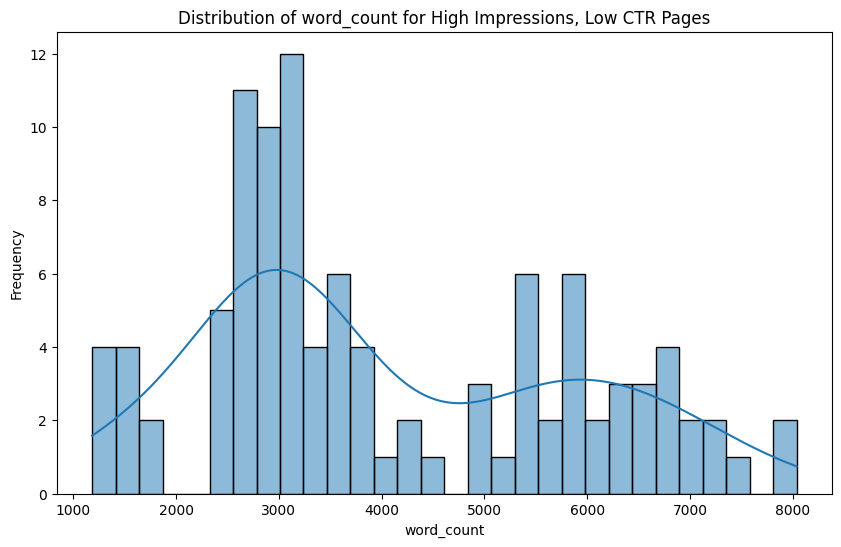

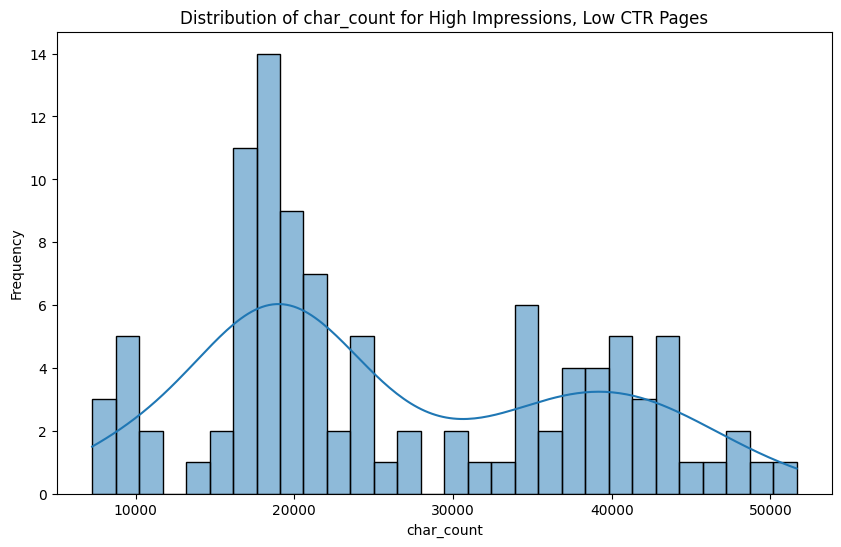

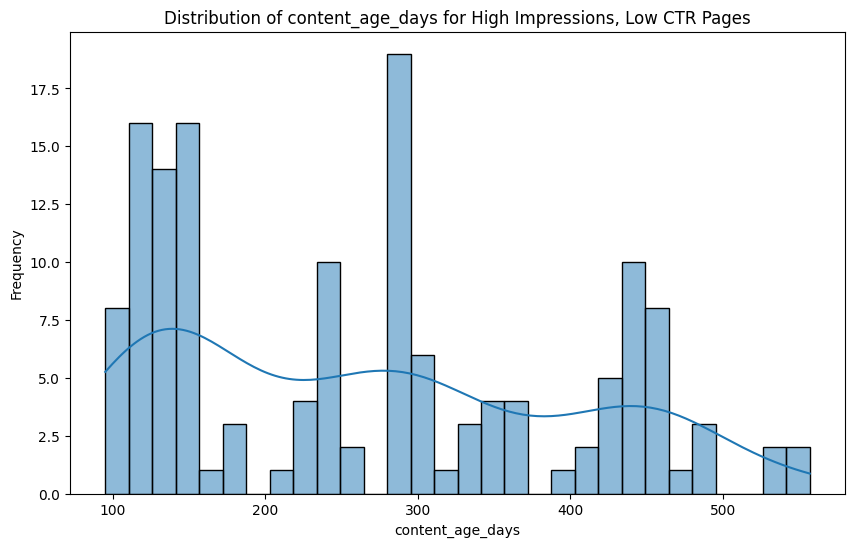

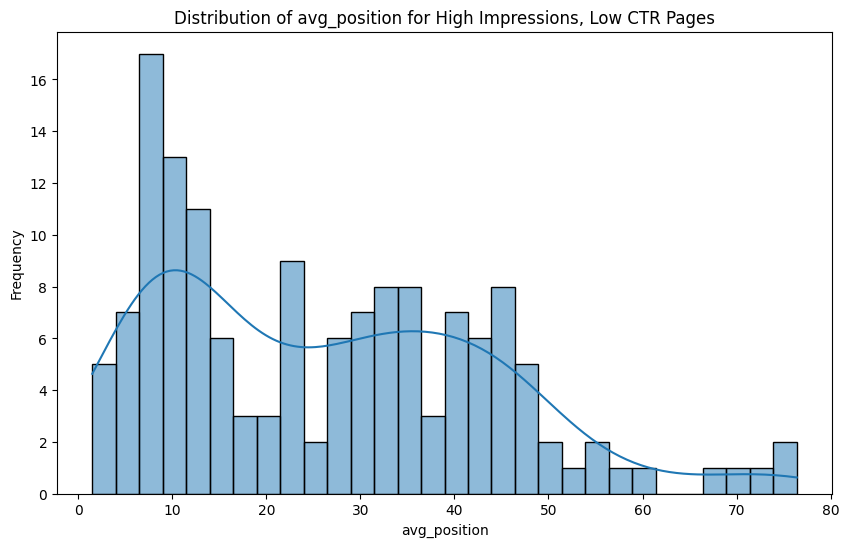

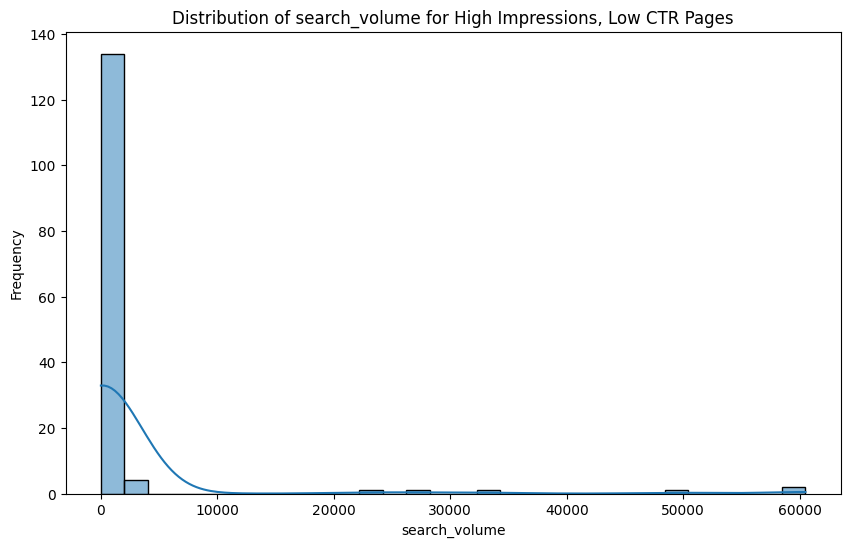

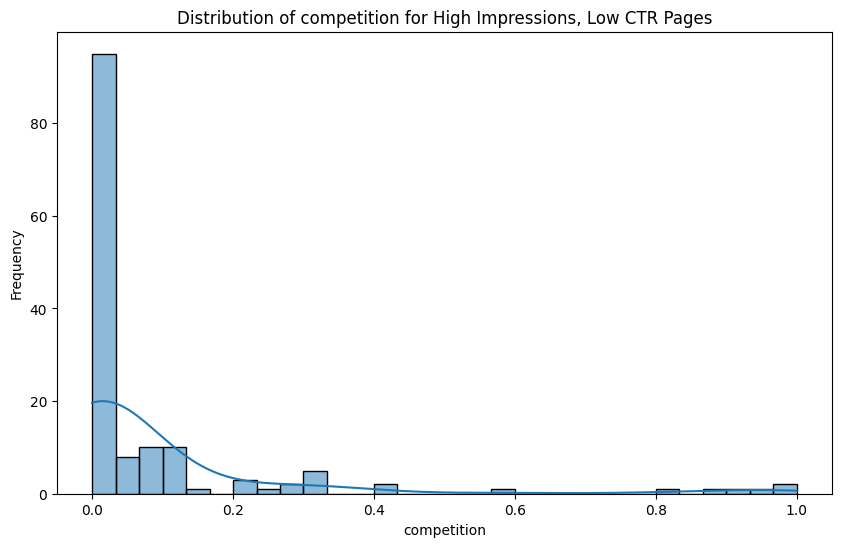

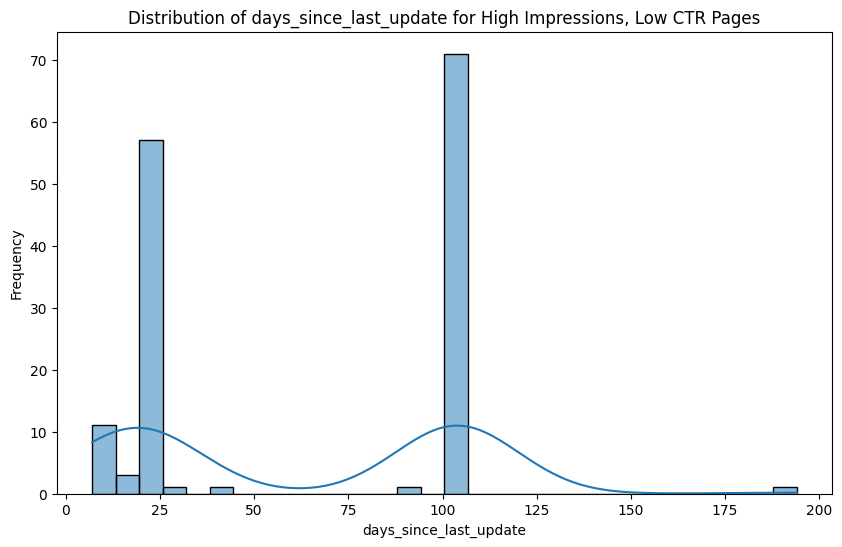

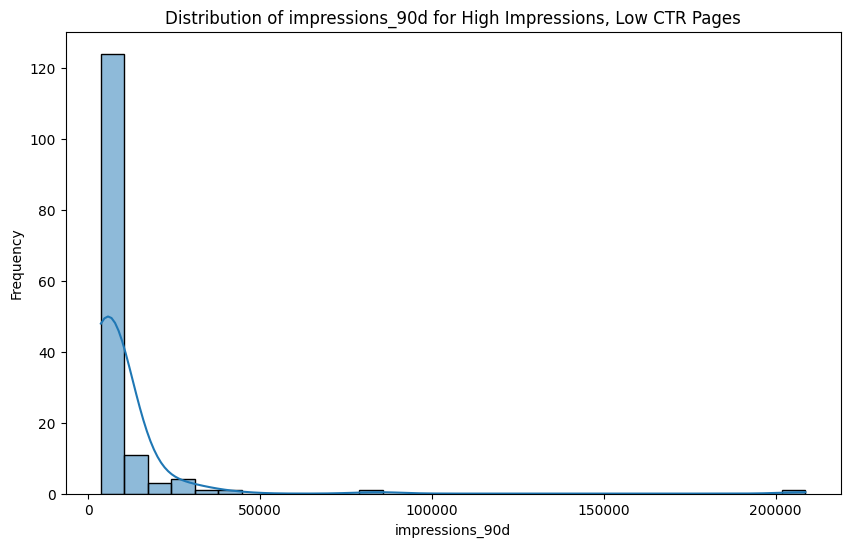

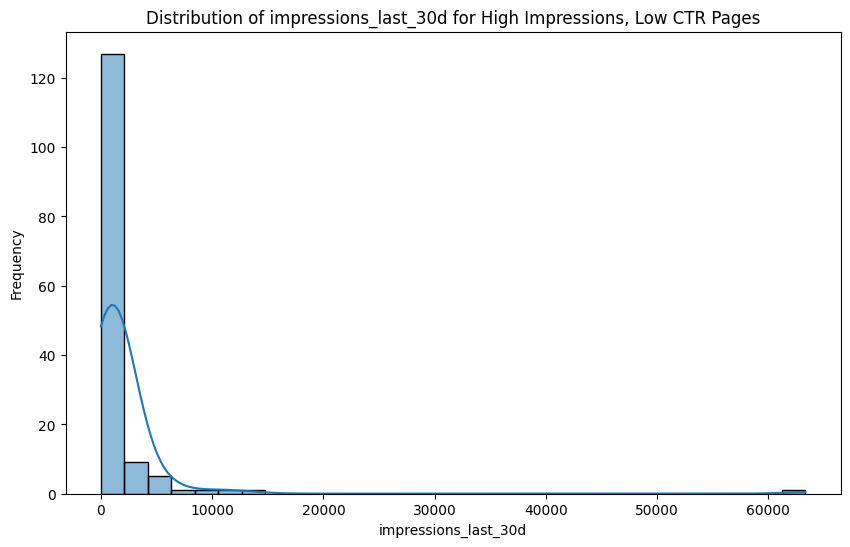

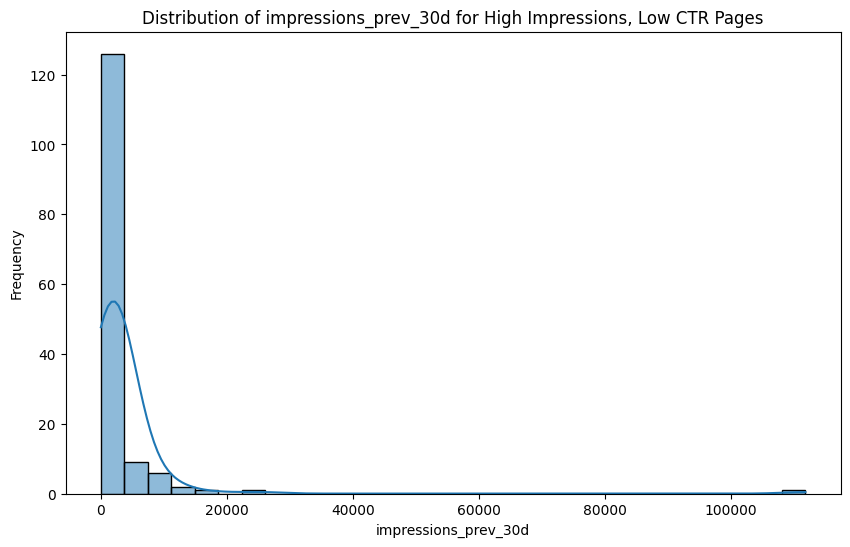

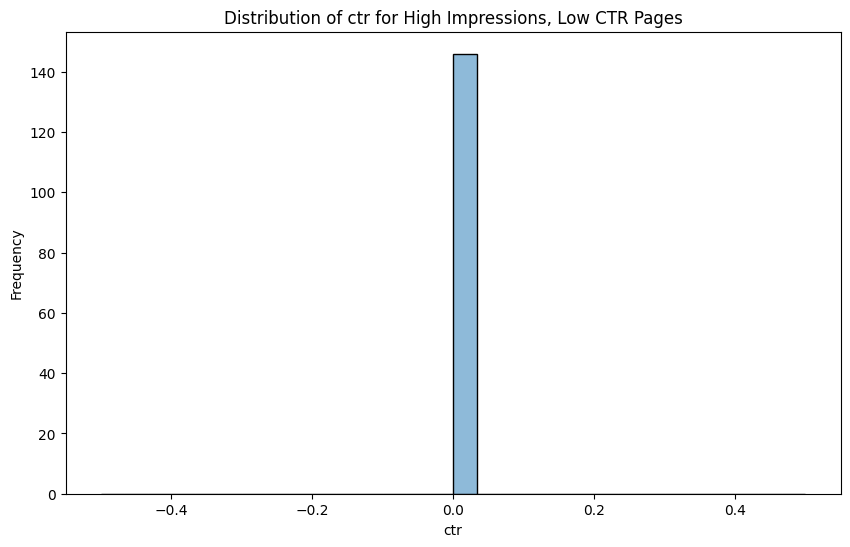

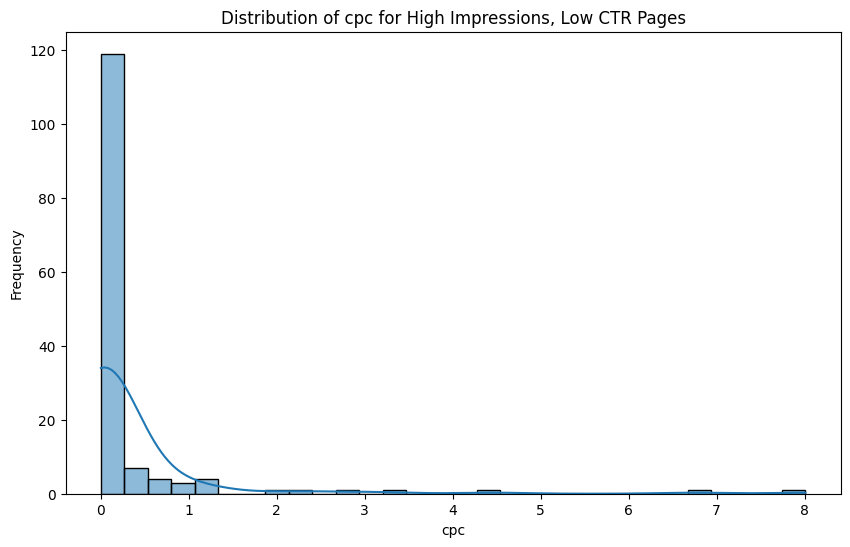

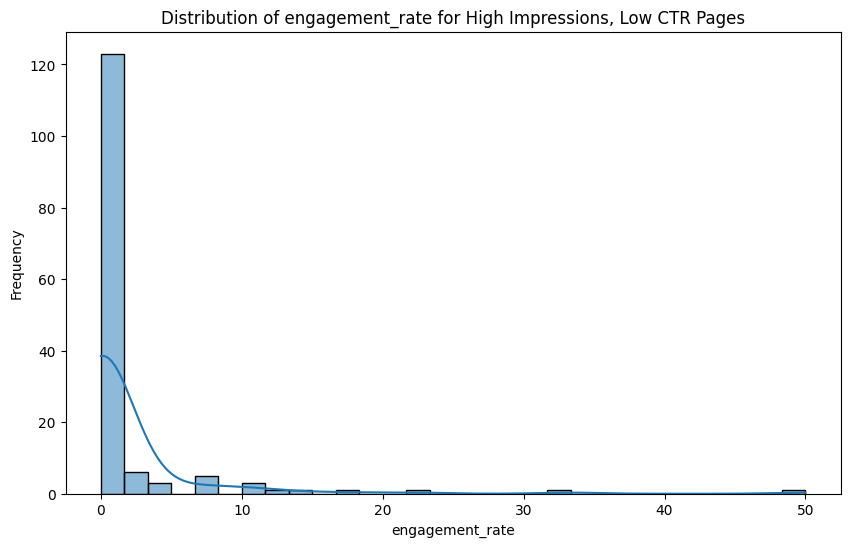

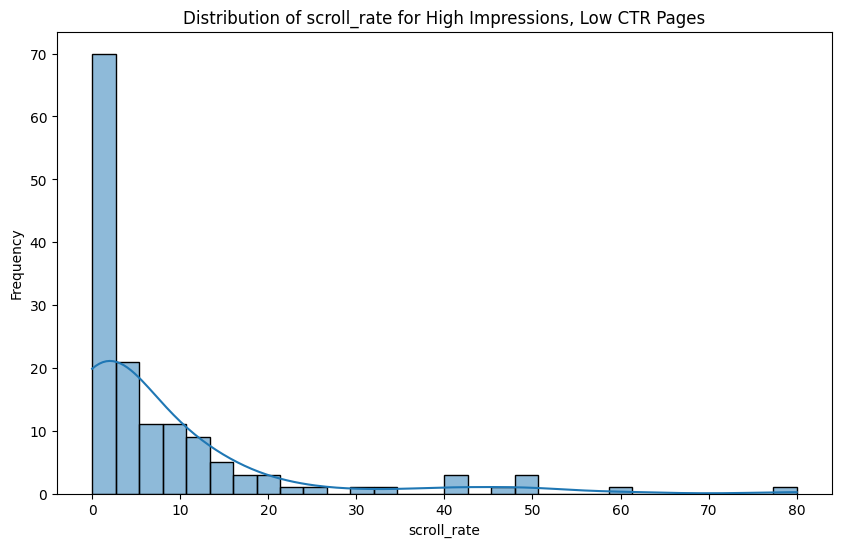

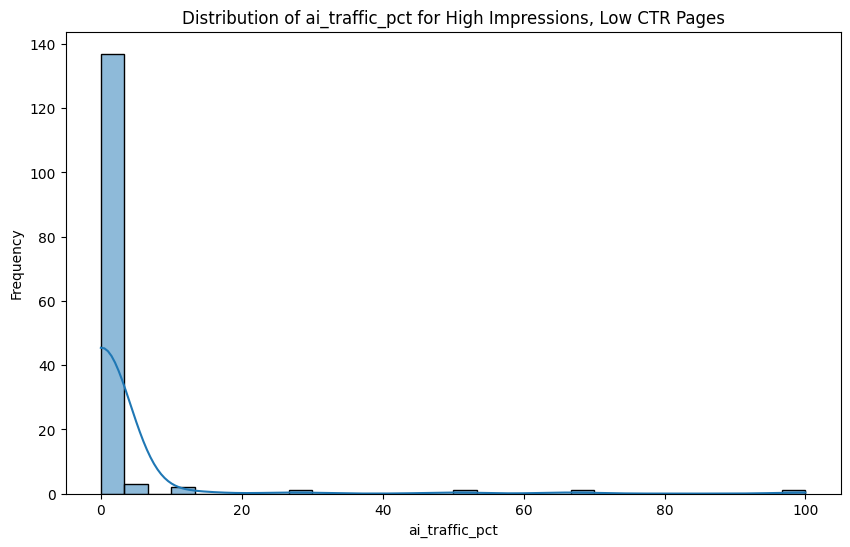

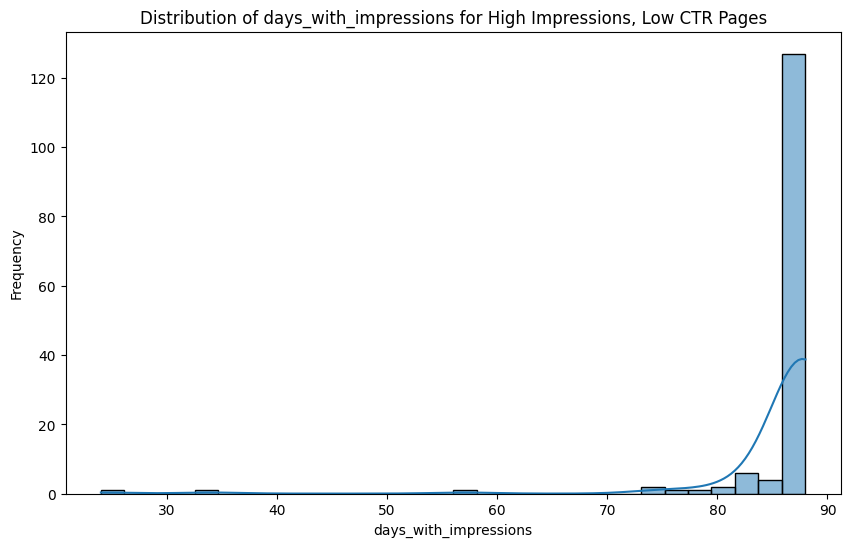

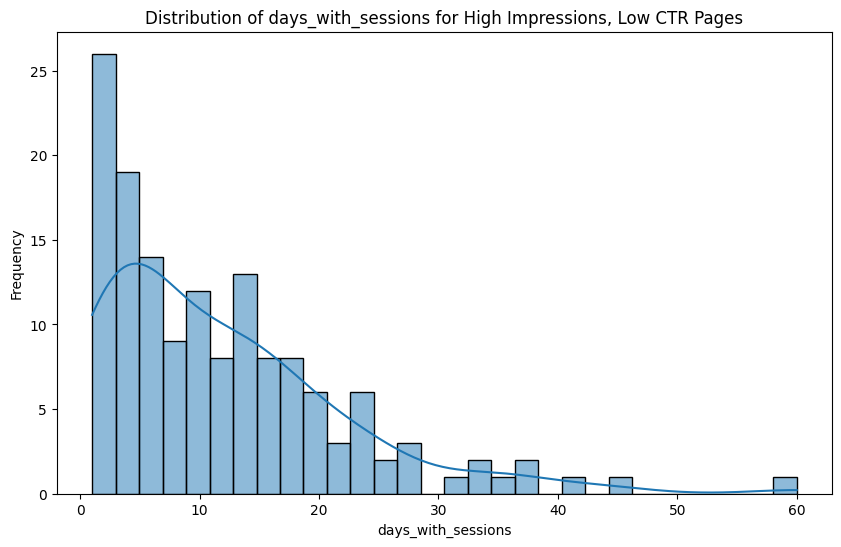


Plotting distributions for categorical columns:


/tmp/ipykernel_1327/3569676809.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_filtered[col], order=df_filtered[col].value_counts().index, palette='viridis')


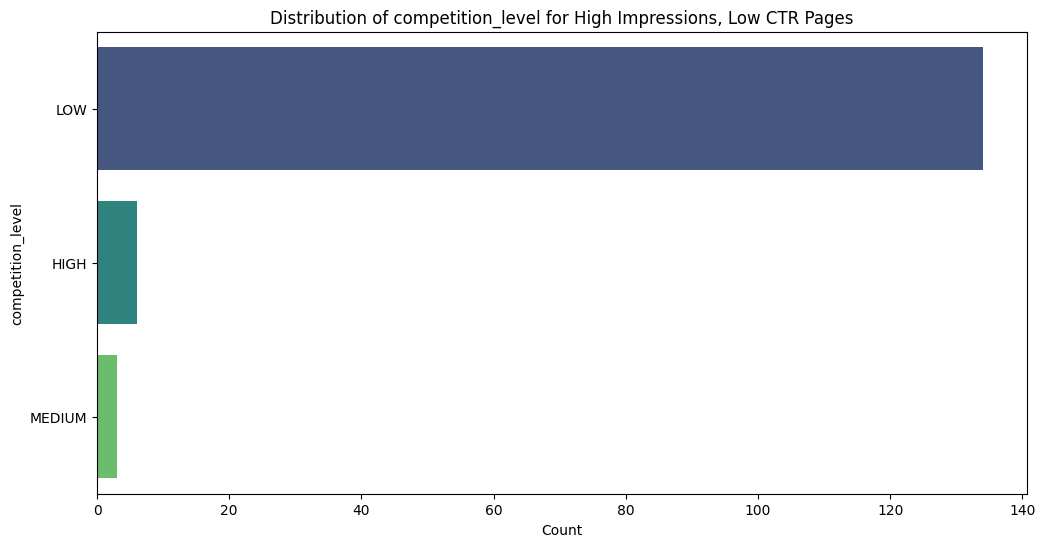

/tmp/ipykernel_1327/3569676809.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_filtered[col], order=df_filtered[col].value_counts().index, palette='viridis')


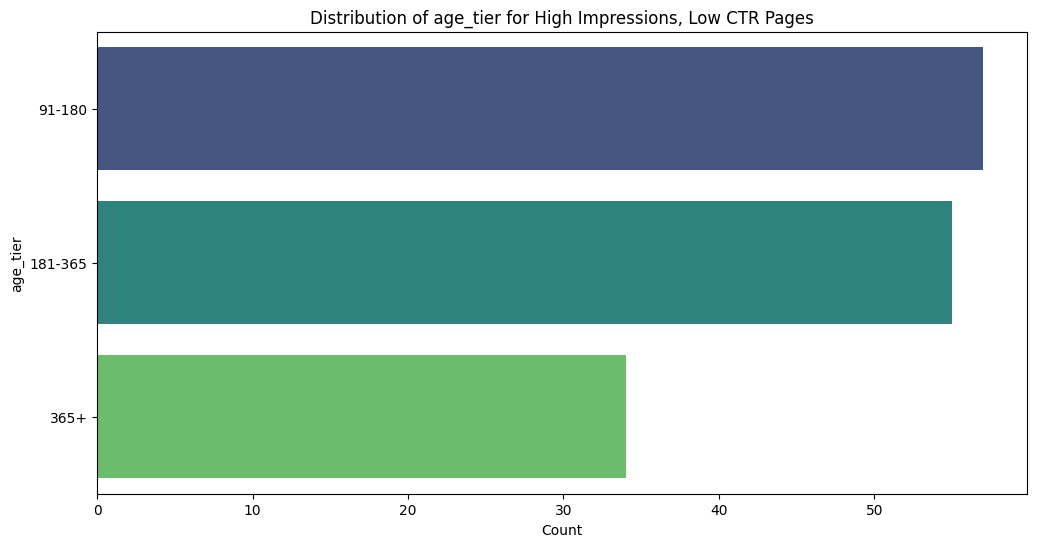

/tmp/ipykernel_1327/3569676809.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_filtered[col], order=df_filtered[col].value_counts().index, palette='viridis')


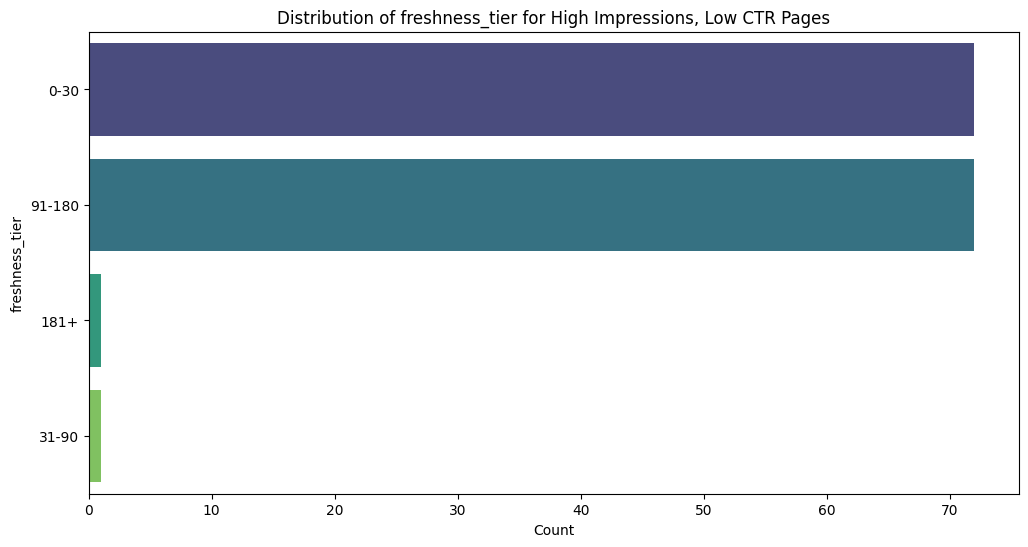

/tmp/ipykernel_1327/3569676809.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_filtered[col], order=df_filtered[col].value_counts().index, palette='viridis')


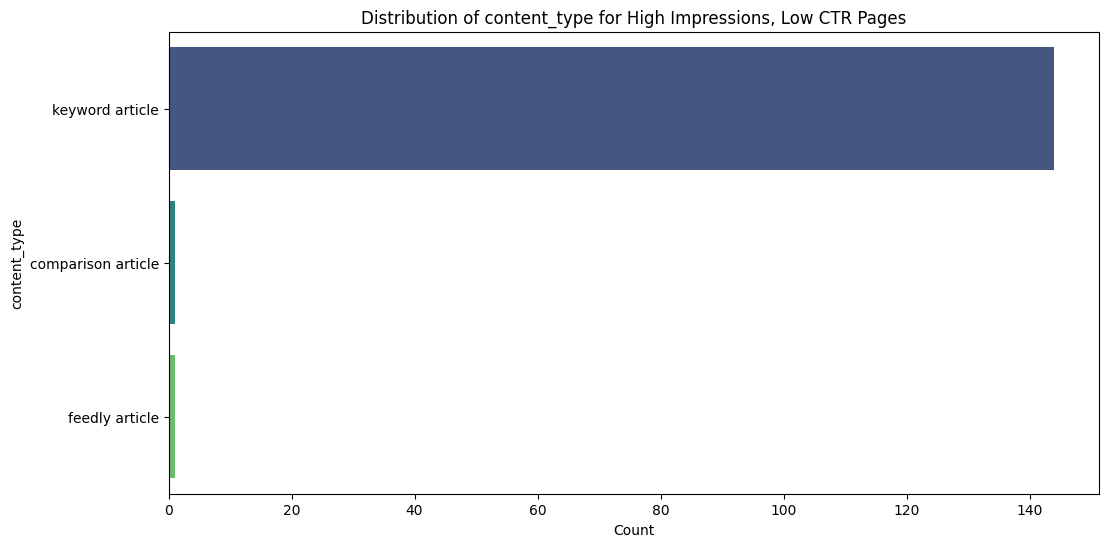

/tmp/ipykernel_1327/3569676809.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_filtered[col], order=df_filtered[col].value_counts().index, palette='viridis')


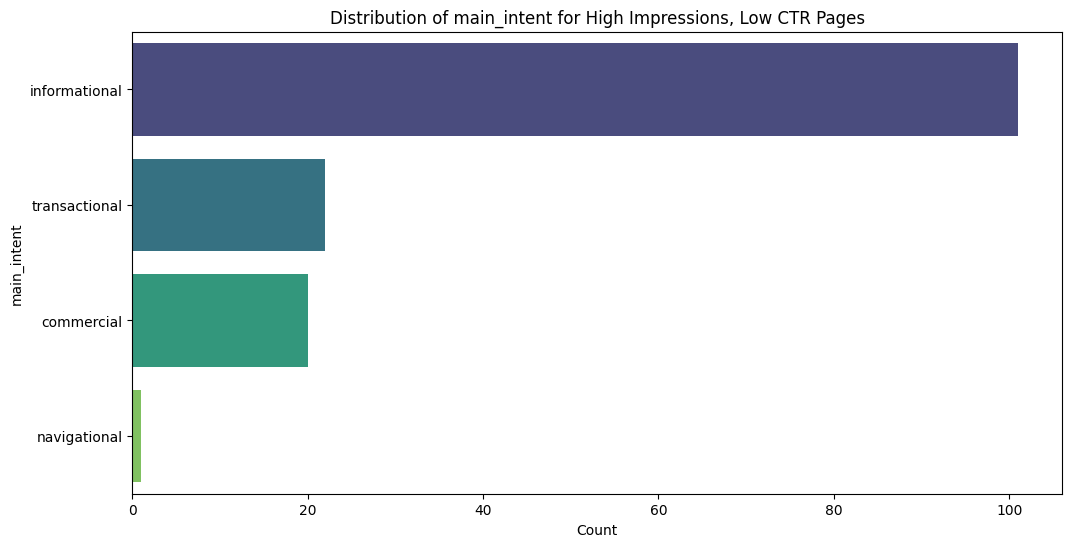

/tmp/ipykernel_1327/3569676809.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_filtered[col], order=df_filtered[col].value_counts().index, palette='viridis')


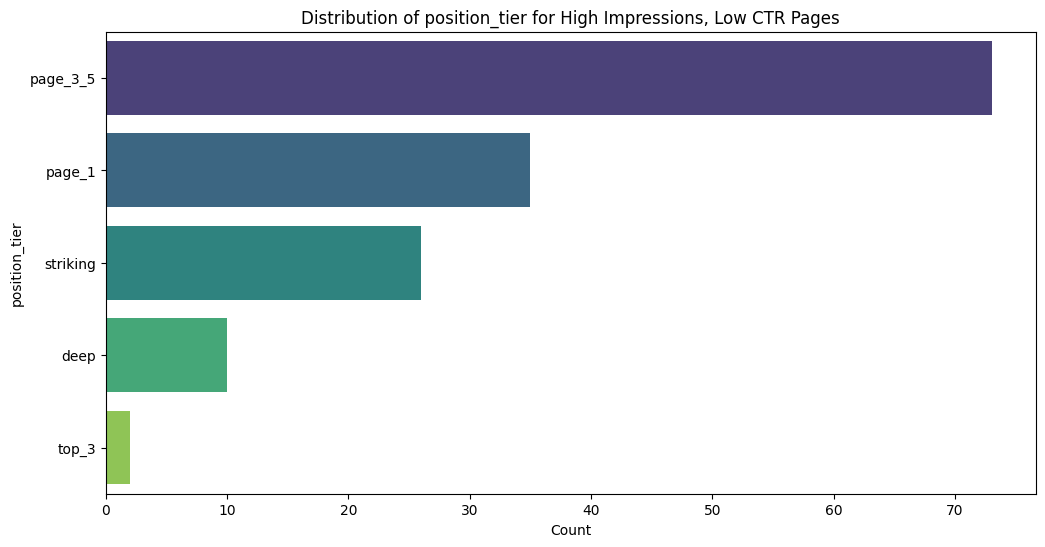

/tmp/ipykernel_1327/3569676809.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_filtered[col], order=df_filtered[col].value_counts().index, palette='viridis')


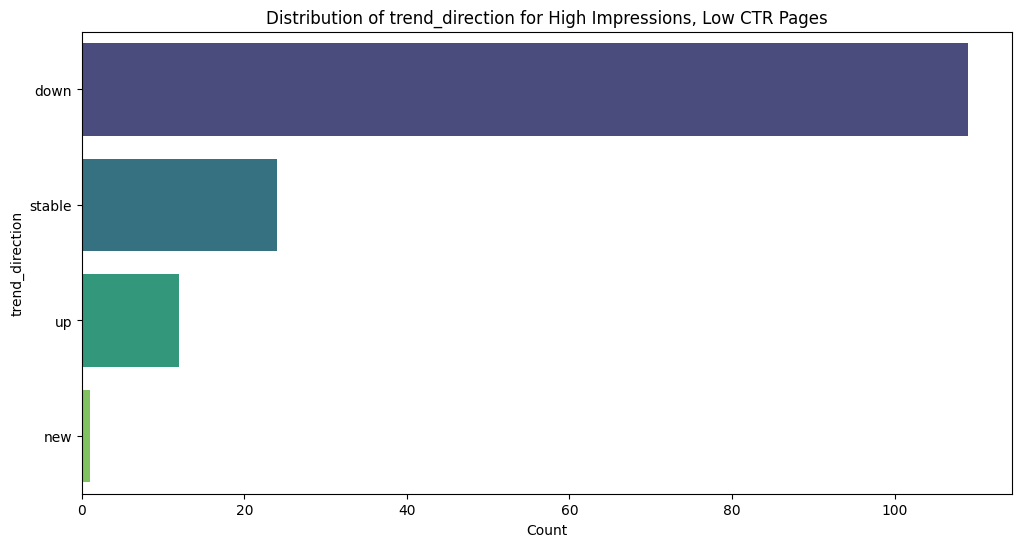

/tmp/ipykernel_1327/3569676809.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_filtered[col], order=df_filtered[col].value_counts().index, palette='viridis')


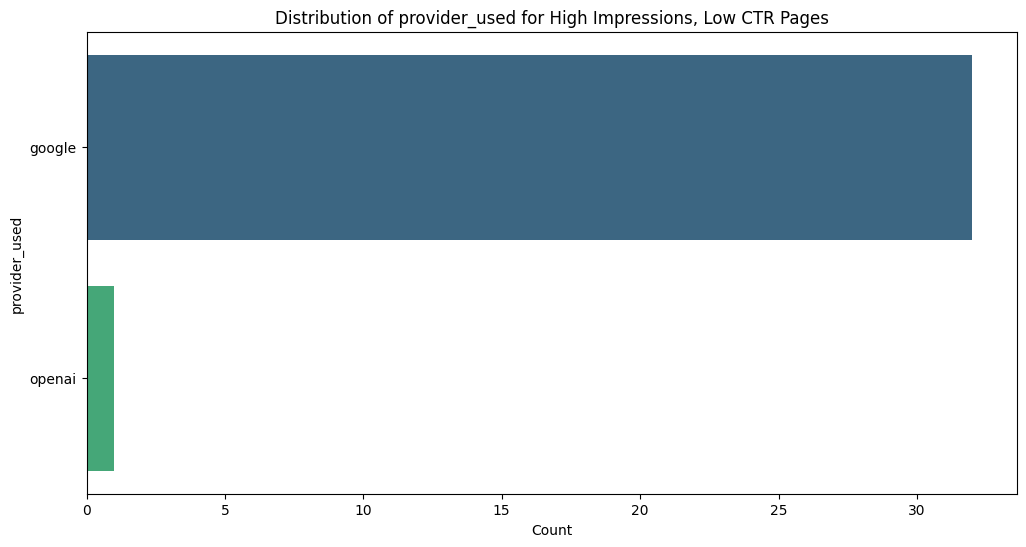

/tmp/ipykernel_1327/3569676809.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_filtered[col], order=df_filtered[col].value_counts().index, palette='viridis')


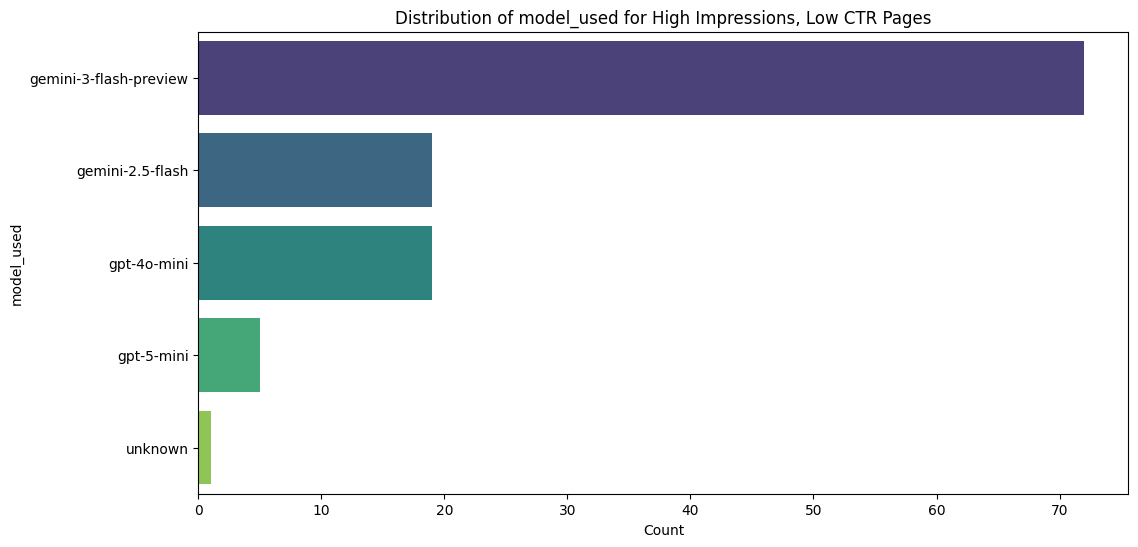

/tmp/ipykernel_1327/3569676809.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_filtered[col], order=df_filtered[col].value_counts().index, palette='viridis')


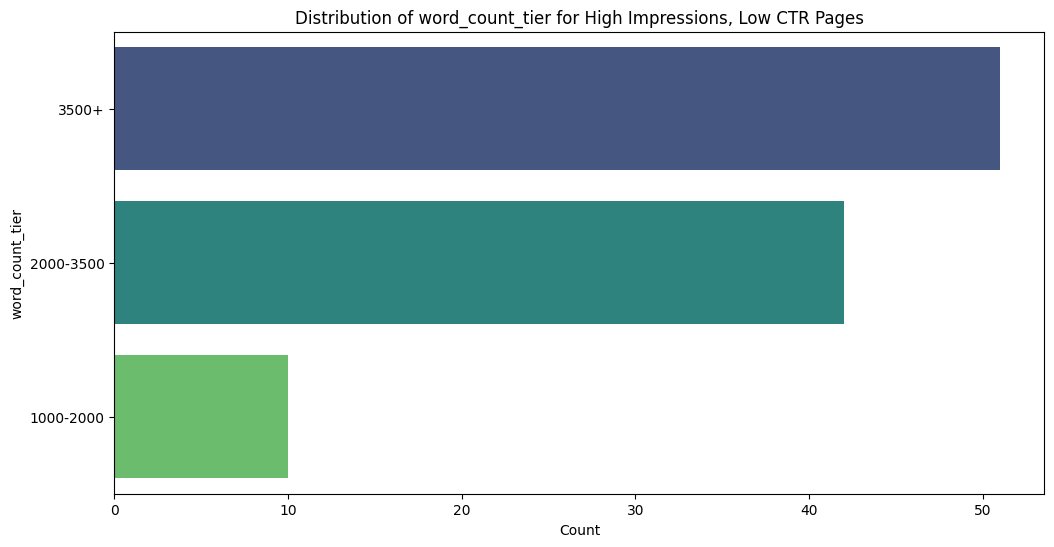

/tmp/ipykernel_1327/3569676809.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_filtered[col], order=df_filtered[col].value_counts().index, palette='viridis')


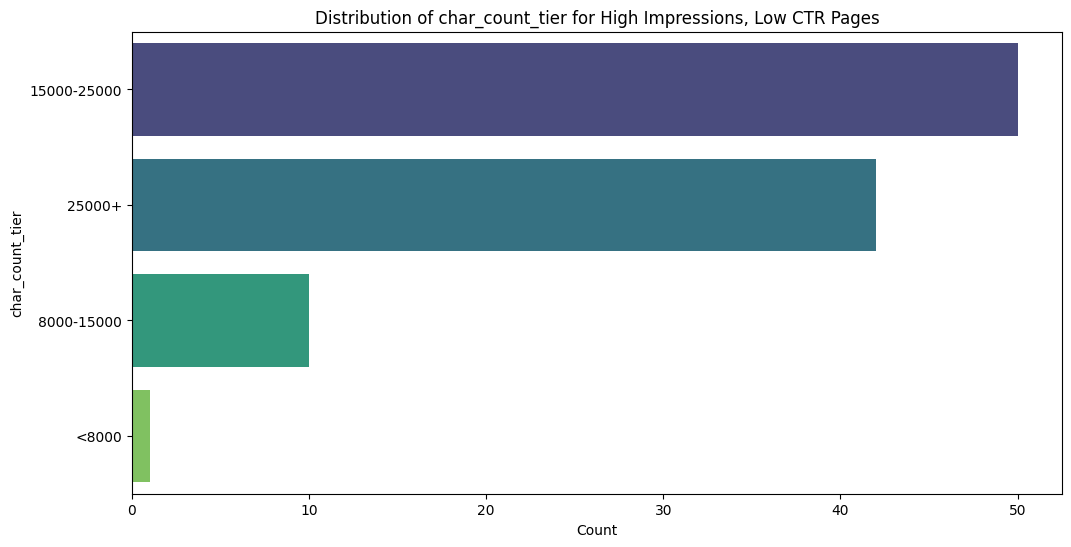

/tmp/ipykernel_1327/3569676809.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_filtered[col], order=df_filtered[col].value_counts().index, palette='viridis')


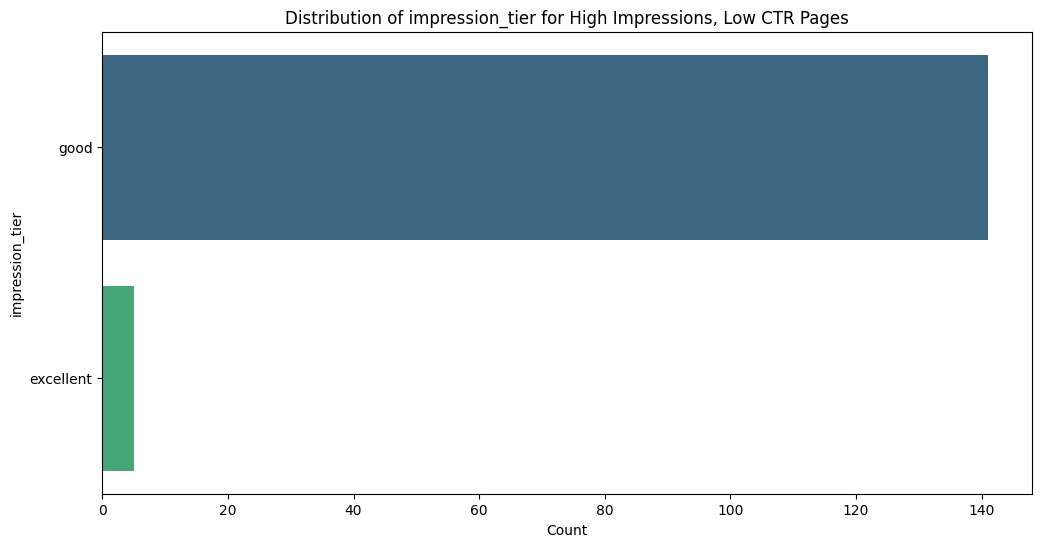

In [5]:
if not df_filtered.empty:
    # --- Numerical Distributions ---
    numerical_cols_to_plot = [
        'word_count', 'char_count', 'content_age_days', 'avg_position',
        'search_volume', 'competition', 'days_since_last_update',
        'impressions_90d', 'impressions_last_30d', 'impressions_prev_30d', 'ctr',
        'cpc', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct',
        'days_with_impressions', 'days_with_sessions'
    ]

    print("\nPlotting distributions for numerical columns:")
    for col in numerical_cols_to_plot:
        if col in df_filtered.columns and df_filtered[col].notna().any():
            plt.figure(figsize=(10, 6))
            sns.histplot(df_filtered[col], bins=30, kde=True)
            plt.title(f'Distribution of {col} for High Impressions, Low CTR Pages')
            plt.xlabel(col)
            plt.ylabel('Frequency')
            plt.show()
        else:
            print(f"Skipping {col}: Not found or all NaN in filtered data.")

    # --- Categorical Distributions ---
    categorical_cols_to_plot = [
        'competition_level', 'age_tier', 'freshness_tier', 'content_type',
        'main_intent', 'position_tier', 'trend_direction',
        'provider_used', 'model_used', 'word_count_tier', 'char_count_tier', 'impression_tier'
    ]

    print("\nPlotting distributions for categorical columns:")
    for col in categorical_cols_to_plot:
        if col in df_filtered.columns and df_filtered[col].notna().any():
            plt.figure(figsize=(12, 6))
            sns.countplot(y=df_filtered[col], order=df_filtered[col].value_counts().index, palette='viridis')
            plt.title(f'Distribution of {col} for High Impressions, Low CTR Pages')
            plt.xlabel('Count')
            plt.ylabel(col)
            plt.show()
        else:
            print(f"Skipping {col}: Not found or all NaN in filtered data.")
else:
    print("Cannot plot distributions as the filtered DataFrame is empty.")

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Signal Test #1, 2: Freshness/Recency of Content

**Hypothesis:** Pages that are either too old (and thus potentially outdated) or very new (and haven't established strong CTR yet) might fall into the high impressions/low CTR bucket. Alternatively, content that hasn't been updated recently might perform poorly.

**Test Idea:** Compare the distribution of `content_age_days` and `days_since_last_update` for the `df_filtered` group (high impressions, low CTR) against the overall dataset (`df`).

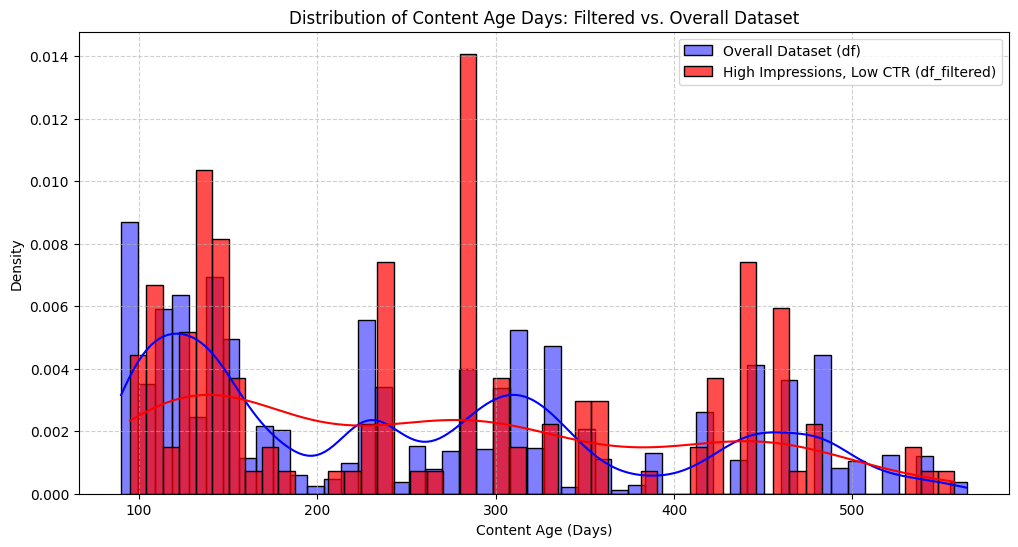

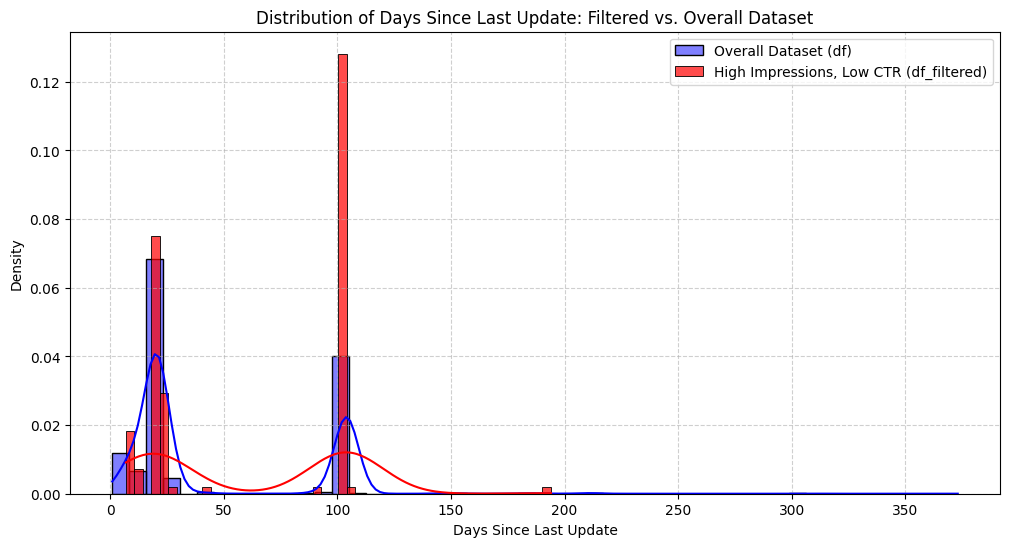

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Signal 1 --- Test for content_age_days ---
plt.figure(figsize=(12, 6))
sns.histplot(df['content_age_days'], bins=50, kde=True, color='blue', label='Overall Dataset (df)', stat='density', alpha=0.5)
sns.histplot(df_filtered['content_age_days'], bins=50, kde=True, color='red', label='High Impressions, Low CTR (df_filtered)', stat='density', alpha=0.7)
plt.title('Distribution of Content Age Days: Filtered vs. Overall Dataset')
plt.xlabel('Content Age (Days)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Signal 2 --- Test for days_since_last_update ---
plt.figure(figsize=(12, 6))
sns.histplot(df['days_since_last_update'].dropna(), bins=50, kde=True, color='blue', label='Overall Dataset (df)', stat='density', alpha=0.5)
sns.histplot(df_filtered['days_since_last_update'].dropna(), bins=50, kde=True, color='red', label='High Impressions, Low CTR (df_filtered)', stat='density', alpha=0.7)
plt.title('Distribution of Days Since Last Update: Filtered vs. Overall Dataset')
plt.xlabel('Days Since Last Update')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Verdict:**

*After observing this plot the one word verdict for these two test signals is CONFIRMED since mostly the red line plots are at the start of  Content Age days/Days since last update axis indicating the recent content so it can fall into high impressions/low ctr bracket similarly there are red lines shown at the end of of this axis as well which can also confirm that pages that are outdated can also have high impressions/low ctr *

### Signal Test #3: Search Volume

**Hypothesis:** Pages with high search volume are more likely to generate high impressions, but if their CTR is low, it represents a significant missed opportunity. Therefore, pages with high impressions and low CTR might disproportionately target high search volume terms.

**Test Idea:** Compare the distribution of `search_volume` for the `df_filtered` group (high impressions, low CTR) against the overall dataset (`df`).

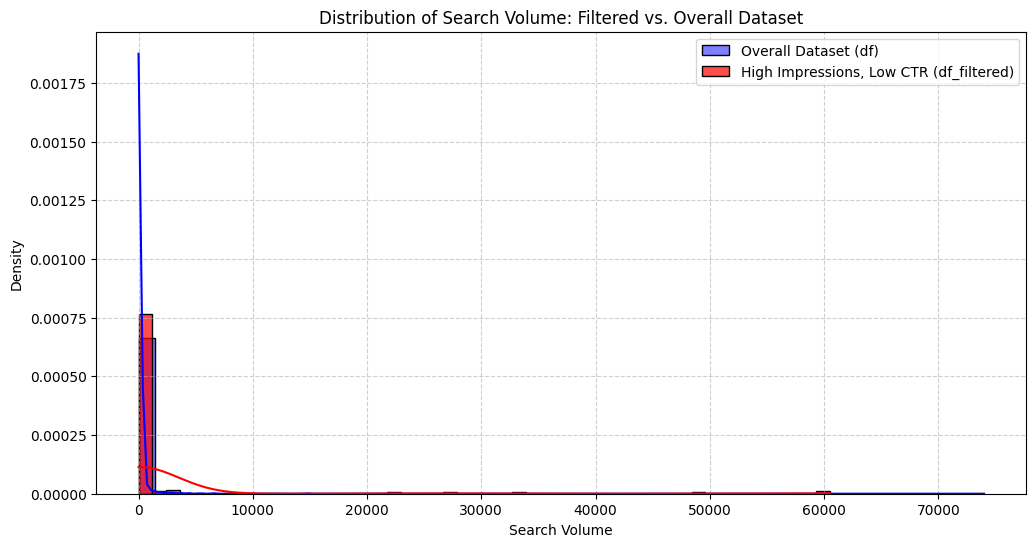

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Test for search_volume ---
plt.figure(figsize=(12, 6))
sns.histplot(df['search_volume'].dropna(), bins=50, kde=True, color='blue', label='Overall Dataset (df)', stat='density', alpha=0.5)
sns.histplot(df_filtered['search_volume'].dropna(), bins=50, kde=True, color='red', label='High Impressions, Low CTR (df_filtered)', stat='density', alpha=0.7)
plt.title('Distribution of Search Volume: Filtered vs. Overall Dataset')
plt.xlabel('Search Volume')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Verdict:**

The plot shows that pages with high impressions and low CTR tend to have a higher density at *lower* search volumes compared to the overall dataset. This is **OPPOSITE** to our hypothesis that they would disproportionately target high search volume terms.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


Among flyrank's real flags we can investigate **CTR vs Position flag** signal to know whether data support's this rule's assumption or not.



### CTR-vs-Position Behind CTR-Fix Logic Rule
This rule checks whether a page's search position affects its CTR. It calculates the average CTR for each search position and plots the relationship. If pages shown at lower average position  receive higher CTRs and pages at higher average position recieve low ctr's than it confirms that position has a strong influence on click-through rate (CTR).

Average CTR by Average Position:


,avg_position,ctr
0,0.0,0.002974
1,0.1,0.000000
2,0.2,0.000371
3,0.3,0.138889
4,0.4,0.003049


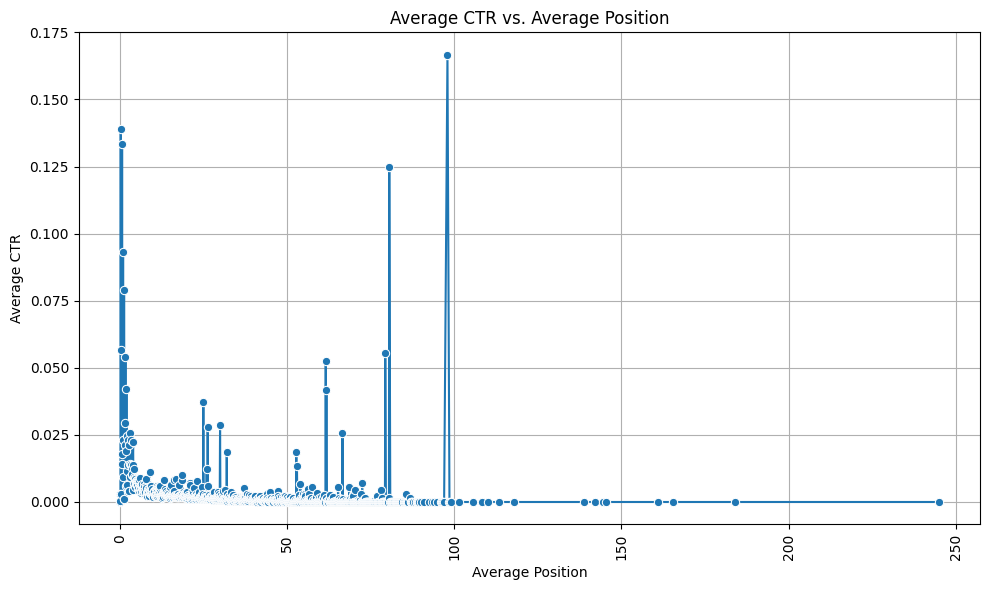

In [8]:
import pandas as pd

# Load the dataset
df_content = pd.read_csv('data/raw/content_refresh_anonymized.csv')

# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Calculate CTR: clicks / impressions
# We'll handle cases where impressions are zero to avoid division by zero errors.
df_content['ctr'] = df_content.apply(
    lambda row: row['clicks_90d'] / row['impressions_90d']
    if row['impressions_90d'] > 0 else 0,
    axis=1
)

# Let's look at the average CTR for each display position.
# We'll only consider positions where there are actual impressions.
avg_ctr_by_position = (
    df_content[df_content['impressions_90d'] > 0]
    .groupby('avg_position')['ctr']
    .mean()
    .reset_index()
)

print("Average CTR by Average Position:")
display(avg_ctr_by_position.head())


# Let's visualize this relationship to make it clearer.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(
    x='avg_position',
    y='ctr',
    data=avg_ctr_by_position,
    marker='o'
)
plt.title('Average CTR vs. Average Position')
plt.xlabel('Average Position')
plt.ylabel('Average CTR')
plt.grid(True)
plt.xticks(rotation=90)  # Rotate x-axis labels if they overlap
plt.tight_layout()       # Adjust layout to prevent labels from being cut off
plt.show()

  Based on the plots shown in this graph the data do support this rule's assumption as there are high peeks of ctr's shown from 0 to 100 position and and as we go above 100 the line becomes flatten confirming position do affect the ctr.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


The content team should prioritize optimizing content that appears at higher average positions (beyond 100), as these pages show a significantly flattened CTR, indicating a lost opportunity for engagement. By improving the relevance, quality, and freshness of this content, they can aim to increase its CTR and potentially drive it to more prominent search positions, thereby maximizing traffic for existing impressions. Additionally, pages with high impressions but low CTR that target *lower* search volumes represent an opportunity to refine targeting or content to better match user intent for specific niches.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.